**Names of all group members:**

Avesta Khaliqi (24-962-763)

Maximilian Flug (24-936-742)

Minghan Yang (24-941-197)

Ken Rölli (20-123-550)

---

All code below is only suggestive and you may as well use different approaches.

## Question 1

### 1. a)

In [1]:
# Exercise 1.
import numpy as np
np.random.seed(0)  # for reproducibility

# simulate explanatory variables x (the age and monthly income are assumed here to follow a continous uniform distribution)
m = 20000
n = 10000

x1 = np.random.uniform(low=18, high=80, size=m+n)
x2 = np.random.uniform(low=1, high=15, size=m+n)
x3 = np.random.binomial(1, 0.1, size=m+n)

# a) calculate empirical means and standard deviations over training data

# We subset entries 1, ..., m=20000 to calculate it only over training data!
x1_mean, x1_std = np.mean(x1[:m]), np.std(x1[:m])
x2_mean, x2_std = np.mean(x2[:m]), np.std(x2[:m])
x3_mean, x3_std = np.mean(x3[:m]), np.std(x3[:m])

print(f"x1 (age) - mean: {x1_mean}, std: {x1_std}")
print(f"x2 (income) - mean: {x2_mean}, std: {x2_std}")
print(f"x3 (employment) - mean: {x3_mean}, std: {x3_std}")

X = np.column_stack((x1, x2, x3))
print(f"X shape: {X.shape}")
X_train = X[:m, :]
X_test = X[m:, :]
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
# b) Can you come up with a few (2 or 3) additional features that may be relevant?
# (you don't have to implement those of course, just write down your answer in text)


x1 (age) - mean: 48.742653896971234, std: 18.0074382841933
x2 (income) - mean: 7.986522193349889, std: 4.030802860686146
x3 (employment) - mean: 0.1017, std: 0.30225338707779603
X shape: (30000, 3)
X_train shape: (20000, 3), X_test shape: (10000, 3)


### 1. b) 
Additional features such as credit history, employment history, and debt-to-income ratio can be considered. The credit history can provide information of previous loan behavior and credit score, which is very important for predicting creditworthiness. The employment history could tell whether the person is able to keep their job and whether they are likely to stay in the status of being employed. The debt-to-income ratio can be an important factor to indicate a borrower's ability to repay a new loan. 
    

## Question 2

### 2. a) Logistic regression

In [2]:
# Exercise 2.
# Building the datasets:

sigmoid = lambda x: 1. / (1. + np.exp(-x))

def p1(x1, x2, x3):
    return sigmoid(13.3 - 0.33 * x1 + 3.5 * x2 - 3 * x3)

def p2(x1, x2, x3):
    return sigmoid(5 - 10 * (np.where(x1 < 25, 1, 0) + np.where(x1 > 75, 1, 0)) + 1.1 * x2 - x3)

xi = np.random.uniform(size=n+m)

# build the first dataset
y1 = np.where(xi <= p1(x1, x2, x3), 1, 0)
y1_train = y1[:m]
y1_test = y1[m:]

# build the second dataset
y2 = np.where(xi <= p2(x1, x2, x3), 1, 0)
y2_train = y2[:m]
y2_test = y2[m:]

In [3]:
# Exercise 2. a)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
# "model = LogisticRegression().fit(X_data, Y_data)" fits a model
# "pred_X = model.predict_proba(X)" evaluates the model
# (note that it outputs both P(Y=0|X) and P(Y=1|X))
# "log_loss(Y, pred_X)" evaluates the negative conditional log likelihood (also called cross-entropy loss)

# Fit the models on both datasets
logreg_model1 = LogisticRegression().fit(X_train, y1_train)
logreg_model2 = LogisticRegression().fit(X_train, y2_train)

# Calculate cross-entropy loss on both datasets for train and test
y1_train_proba_logreg = logreg_model1.predict_proba(X_train)
y1_test_proba_logreg = logreg_model1.predict_proba(X_test)

y2_train_proba_logreg = logreg_model2.predict_proba(X_train)
y2_test_proba_logreg = logreg_model2.predict_proba(X_test)

ce1_logreg_train = log_loss(y1_train, y1_train_proba_logreg)
ce1_logreg_test = log_loss(y1_test, y1_test_proba_logreg)

ce2_logreg_train = log_loss(y2_train, y2_train_proba_logreg)
ce2_logreg_test = log_loss(y2_test, y2_test_proba_logreg)

print(f"Cross Entropy of logistic regression model 1 - Train: {ce1_logreg_train:.3f}, Test: {ce1_logreg_test:.3f}")
print(f"Cross Entropy of logistic regression model 2 - Train: {ce2_logreg_train:.3f}, Test: {ce2_logreg_test:.3f}")


Cross Entropy of logistic regression model 1 - Train: 0.030, Test: 0.035
Cross Entropy of logistic regression model 2 - Train: 0.154, Test: 0.149


### 2. b) Fit SVM

In [4]:
# Exercise 2. b)
# Calculate normalized data

# We already calculated the empirical std in Exercise 1.
# Now we divide both training and test observations by the training std.
x1_normalized = x1 / x1_std
x2_normalized = x2 / x2_std
x3_normalized = x3 / x3_std

X_normalized = np.column_stack((x1_normalized, x2_normalized, x3_normalized))
X_normalized_train = X_normalized[:m, :]
X_normalized_test = X_normalized[m:, :]

In [ ]:
from sklearn.svm import SVC
# "model = SVC(kernel='rbf', gamma=GAMMA, C=C, probability=True)" creates
# a model with kernel exp(-GAMMA \|x-x'\|_2^2) and regul. parameter C (note the relation between C and the parameter lambda from the lecture).
# "probability=True" enables the option "model.predict_proba(X)" to predict probabilities from the regression function \hat{f}^{svm}.
# "model.fit(X, Y)" optimizes the model parameters (using hinge loss)

# Fit the models for both datasets (this can take up to 60 seconds with SVC)
lambda_regul = 5 / (2 * m)
C = 1 / (2 * lambda_regul * m)

svm_model1 = SVC(kernel='rbf', gamma=1.0/10, C=C, probability=True)
svm_model1.fit(X_normalized_train, y1_train)

svm_model2 = SVC(kernel='rbf', gamma=1.0/10, C=C, probability=True)
svm_model2.fit(X_normalized_train, y2_train);


0.2

In [6]:
# Exercise 2.b (iii)
# "model.predict_proba(X)" predicts probabilities from features (note that it outputs both P(Y=0|X) and P(Y=1|X))
y1_train_proba_svm = svm_model1.predict_proba(X_normalized_train)
y1_test_proba_svm = svm_model1.predict_proba(X_normalized_test)

y2_train_proba_svm = svm_model2.predict_proba(X_normalized_train)
y2_test_proba_svm = svm_model2.predict_proba(X_normalized_test)


# Calculate cross-entropy loss on both normalized datasets for train and test
ce1_svm_train = log_loss(y1_train, y1_train_proba_svm)
ce1_svm_test = log_loss(y1_test, y1_test_proba_svm)

ce2_svm_train = log_loss(y2_train, y2_train_proba_svm)
ce2_svm_test = log_loss(y2_test, y2_test_proba_svm)

print(f"Cross Entropy of svm model 1 - Train: {ce1_svm_train:.3f}, Test: {ce1_svm_test:.3f}")
print(f"Cross Entropy of svm model 2 - Train: {ce2_svm_train:.3f}, Test: {ce2_svm_test:.3f}")


Cross Entropy of svm model 1 - Train: 0.032, Test: 0.039
Cross Entropy of svm model 2 - Train: 0.071, Test: 0.067


### 2. b) (iv) 
**No results will change** in model behaviour for the SVM with RBF kernel, provided we apply the same transformation to train and test data. Normalization and standardization only differ by a shift of the empirical mean. 
We have that $\tilde{z}_{ij} = \tilde{x}_{ij} - \frac{\hat{\mu_j}}{\hat{\sigma}}$. So by using standardized data we would just shift the location of our data (by $- \frac{\hat{\mu_j}}{\hat{\sigma}}$ for $j = 1, 2, 3$).
Our kernel $\exp(-\frac{1}{10} \lVert x - x' \rVert ^2)$ only depends on the distance between the points $x$ and $x'$. If we shift both by the same location vector (as it is done for standardization compared to normalization), the resulting distance between the same points will be the same.
Hence also the same value after evaluating the kernel.

### 2. c) FDR/TPR-curves and AUC

=== Logistic Regression, Dataset 1 ===
AUC ≈ 0.0003

=== Logistic Regression, Dataset 2 ===
AUC ≈ 0.0079

=== SVM (RKHS) Regression, Dataset 1 ===
AUC ≈ 0.0003

=== SVM (RKHS) Regression, Dataset 2 ===
AUC ≈ 0.0011


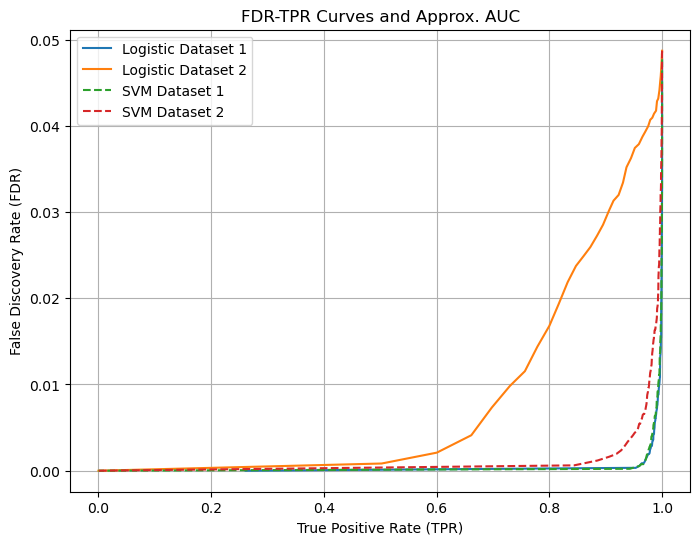

In [9]:
# Exercise 2.c
import matplotlib.pyplot as plt
# To calculate the curves, it is fine to take 100 threshold values c, i.e.,
ths = np.linspace(0, 1, 100)

# To approximately calculate the AUC, it is fine to simply use Riemann sums.
# This means, if you have 100 (a_i, b_i) pairs for the curves, a_1 <= a_2 <= ...
# then you may simply use the sum
# sum_{i=1}^99 (b_i + b_{i+1})/2 * (a_{i+1}-a_i)
# as the approximation of the integral (or AUC)

# Function to compute FDR, TPR, and approximate AUC via Riemann sums
def fdr_tpr_auc(y_true, probs, ths):
    tpr_vals = []
    fdr_vals = []
    for c in ths:
        pred = (probs >= c).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        FN = np.sum((pred == 0) & (y_true == 1))
        if (TP + FN) > 0:
            TPR = TP / (TP + FN)
        else:
            TPR = 0.0
        if (TP + FP) > 0:
            FDR = FP / (TP + FP)
        else:
            FDR = 0.0
        tpr_vals.append(TPR)
        fdr_vals.append(FDR)
    tpr_vals = np.array(tpr_vals)
    fdr_vals = np.array(fdr_vals)
    # Approximate AUC using Riemann sum method from assignment
    AUC = np.sum(( tpr_vals[:-1]-tpr_vals[1:]) / 2 * (fdr_vals[1:] + fdr_vals[:-1]))
    return fdr_vals, tpr_vals, AUC


# -----------------------------
# first data set & logistic regression:
print("=== Logistic Regression, Dataset 1 ===")
fdr1_log, tpr1_log, auc1_log = fdr_tpr_auc(y1_test, y1_test_proba_logreg[:,1], ths)
print(f"AUC ≈ {auc1_log:.4f}")

# second data set & logistic regression:
print("\n=== Logistic Regression, Dataset 2 ===")
fdr2_log, tpr2_log, auc2_log = fdr_tpr_auc(y2_test, y2_test_proba_logreg[:,1], ths)
print(f"AUC ≈ {auc2_log:.4f}")

# first data set & SVM (RKHS regression):
print("\n=== SVM (RKHS) Regression, Dataset 1 ===")
fdr1_svm, tpr1_svm, auc1_svm = fdr_tpr_auc(y1_test, y1_test_proba_svm[:,1], ths)
print(f"AUC ≈ {auc1_svm:.4f}")

# second data set & SVM (RKHS regression):
print("\n=== SVM (RKHS) Regression, Dataset 2 ===")
fdr2_svm, tpr2_svm, auc2_svm = fdr_tpr_auc(y2_test, y2_test_proba_svm[:,1], ths)
print(f"AUC ≈ {auc2_svm:.4f}")


# -----------------------------
# Plot FDR/TPR curves
plt.figure(figsize=(8, 6))
plt.plot( tpr1_log, fdr1_log, label='Logistic Dataset 1')
plt.plot( tpr2_log, fdr2_log, label='Logistic Dataset 2')
plt.plot( tpr1_svm, fdr1_svm, '--', label='SVM Dataset 1')
plt.plot( tpr2_svm, fdr2_svm, '--', label='SVM Dataset 2')
plt.xlabel('True Positive Rate (TPR)')
plt.ylabel('False Discovery Rate (FDR)')
plt.title('FDR-TPR Curves and Approx. AUC')
plt.legend()
plt.grid(True)
plt.show()

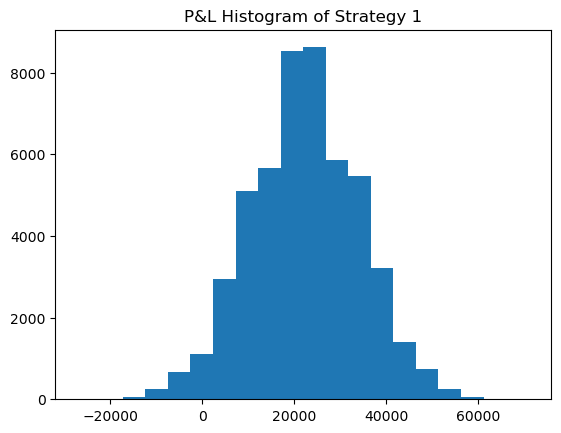

Expected Profit: 22360.023, 95%-VaR: -2455.000


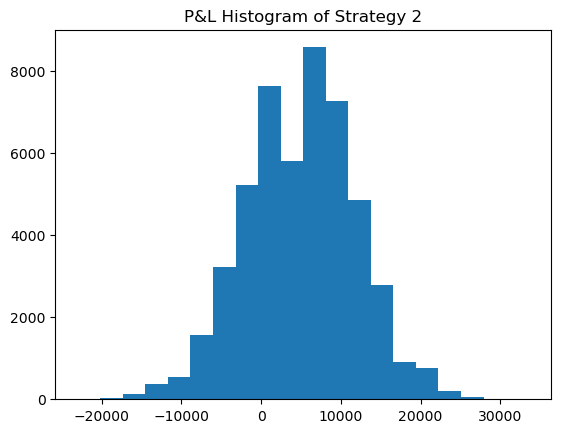

Expected Profit: 4874.828, 95%-VaR: 6840.000


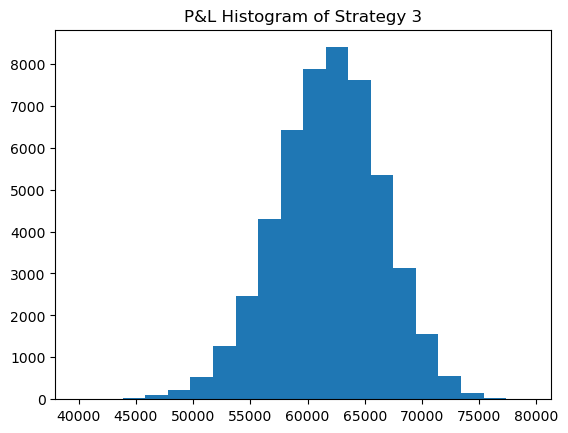

Expected Profit: 61939.698, 95%-VaR: -54070.000


In [ ]:
# Exercise 3.

# Set model parameters and define matrix D
K = 50_000
xi_matrix = np.random.uniform(size=(n, K))
p2_test = p2(x1, x2, x3)[m:]
D = np.where(xi_matrix <= p2_test[:, np.newaxis], 1, 0)


# Strategy 1:
# Define Portfolio and possible outcomes for this portfolio using matrix D
# If there is a 0 in the D matrix, the person in this scenario accounts gives a loss of 1000 (i.e. -1000 P&L).
# If there is a 1 in the D matrix, the person in this scenario accounts gives a profit of 5.5% of 1000 (i.e. 55 P&L)
# This can be calculated efficiently by multiplying D by 1055 (if entry in D is zero, it will stay zero, otherwise it will become 1055)
# and then subtracting 1000 for all person and scenarios.
# In the end for every scenario we need to sum over all the persons (rows), i.e. axis=0.
# giving us the profit and loss for every scenario (we have 50000 scenarios).
profit_and_losses_strategy_1 = np.sum(D * 1055 - 1000, axis=0)

# Plot histogram of profits and losses
plt.hist(profit_and_losses_strategy_1, bins=20)
plt.title("Profit & Loss Histogram of Strategy 1")
plt.show()

# Calculate expected profit and losses and 95%-VaR
pl_strategy_1 = np.mean(profit_and_losses_strategy_1)
var_strategy_1 = -np.quantile(profit_and_losses_strategy_1, 0.05)
print(f"Expected Profit: {pl_strategy_1:.3f}, 95%-VaR: {var_strategy_1:.3f}")


# Strategy 2:
# Define Portfolio and possible outcomes using the matrix D and the predicted default probabilities from the logistic regression model
D_strategy_2_selection = D[y2_test_proba_logreg[:, 1] >= 0.95, :]
profit_and_losses_strategy_2 = np.sum(D_strategy_2_selection * 1010 - 1000, axis=0)
# Plot histogram of profits and losses
plt.hist(profit_and_losses_strategy_2, bins=20)
plt.title("Profit & Loss Histogram of Strategy 2")
plt.show()

# Calculate expected profit and losses and 95%-VaR
pl_strategy_2 = np.mean(profit_and_losses_strategy_2)
var_strategy_2 = -np.quantile(profit_and_losses_strategy_2, 0.05)
print(f"Expected Profit: {pl_strategy_2:.3f}, 95%-VaR: {var_strategy_2:.3f}")

# Strategy 3:
# Define Portfolio and possible outcomes using the matrix D and the predicted default probabilities from the rkhs model
D_strategy_3_selection = D[y2_test_proba_svm[:, 1] >= 0.95, :]
profit_and_losses_strategy_3 = np.sum(D_strategy_3_selection * 1010 - 1000, axis=0)
# Plot histogram of profits & losses (which is simply the performance of each strategy in scenario k, i.e. a profit if positive or a loss if negative)
plt.hist(profit_and_losses_strategy_3, bins=20)
plt.title("Profit & Loss Histogram of Strategy 3")
plt.show()

# Calculate expected profit & losses and 95%-VaR for each strategy
pl_strategy_3 = np.mean(profit_and_losses_strategy_3)
var_strategy_3 = -np.quantile(profit_and_losses_strategy_3, 0.05)
print(f"Expected Profit: {pl_strategy_3:.3f}, 95%-VaR: {var_strategy_3:.3f}")